# Praktikum 4: Transformer

Tjark Pfeiffer und Fiona Lublow

## Ziele

Wir untersuchen die Implementierung eines Transformers zum Übersetzen von kurzen Texten, und versuchen insbesondere die Eigenschaften der Attention-Mechanismen durch Visualisierungen besser zu verstehen.

Als Grundlage nutzen wir die Implementierung aus dem Tutorial [building-a-transformer-with-py-torch](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch).


In [1]:
import torch.nn as nn
import torch.optim as optim
import math

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Ensure that the model dimension (d_model) is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Initialize dimensions
        self.d_model = d_model # Model's dimension
        self.num_heads = num_heads # Number of attention heads
        self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs
        self.W_q = nn.Linear(d_model, d_model) # Query transformation
        self.W_k = nn.Linear(d_model, d_model) # Key transformation
        self.W_v = nn.Linear(d_model, d_model) # Value transformation
        self.W_o = nn.Linear(d_model, d_model) # Output transformation

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)

        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [3]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [5]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [6]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [7]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length, device=tgt.device), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

# Vorgehen

Wir evaluieren verschiedene englisch-deutsch Datensätze, und entscheiden uns für [Multi30k](http://www.aclweb.org/anthology/W16-3210). Dieser Datensatz enthält Beschreibungen von Bildern, unsere Trainingsdaten sind also auf diese objektive, deskriptive Formulierungen und Wörter begrenzt.

Andere, allgemeinere Datensätze sind zu groß für unser Prototyping ([OPUS Transweb en-de](https://opus.nlpl.eu/synthetic/transweb-edu.php)), oder enthalten viele sinnlose Sätze ([OPUS-100](https://huggingface.co/datasets/Helsinki-NLP/opus-100/viewer/de-en)).

In [8]:
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import torch

d_model = 256
num_heads = 4
num_layers = 3
d_ff = 1024
dropout = 0.1
max_seq_length = 100

num_epochs = 25

# Load Multi30k German-English dataset
dataset = load_dataset("bentrevett/multi30k")

# ------------------------------------------------------------
# Vocabulary builder
# ------------------------------------------------------------

def build_vocab(texts, max_size):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {token: idx + 4 for idx, (token, _) in enumerate(counter.most_common(max_size - 4))}
    vocab.update({"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3})
    return vocab

src_texts = [ex['de'] for ex in dataset['train']]
tgt_texts = [ex['en'] for ex in dataset['train']]

src_vocab = build_vocab(src_texts, 5000)
tgt_vocab = build_vocab(tgt_texts, 5000)

# ------------------------------------------------------------
# Encoding function
# ------------------------------------------------------------

def encode(text, vocab, max_len=100):
    tokens = ["<sos>"] + text.split()[:max_len-2] + ["<eos>"]
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

class TranslationDataset(Dataset):
    def __init__(self, dataset_split, src_vocab, tgt_vocab, max_len=100):
        self.data = dataset_split
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src = encode(self.data[idx]['de'], self.src_vocab, self.max_len)
        tgt = encode(self.data[idx]['en'], self.tgt_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

train_dataset = TranslationDataset(dataset['train'], src_vocab, tgt_vocab, max_seq_length)
val_dataset = TranslationDataset(dataset['validation'], src_vocab, tgt_vocab, max_seq_length)
test_dataset = TranslationDataset(dataset['test'], src_vocab, tgt_vocab, max_seq_length)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# Update model params
src_vocab_size = len(src_vocab)
tgt_vocab_size = len(tgt_vocab)

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

In [ ]:
%%script echo skipping

# load this to use the pretrained model

transformer = torch.load("./transformer.pt")

Zuerst trainieren wir nur zwei Epochen, um zu verifizieren, das unser Modell und Dataset zu einem akzeptablen Ergebnis führt.

In [10]:
%%script echo skipping

from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transformer = transformer.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()

num_epochs = 2

for epoch in range(num_epochs):
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for src_data, tgt_data in progress_bar:
        src_data = src_data.to(device)
        tgt_data = tgt_data.to(device)

        optimizer.zero_grad()
        output = transformer(src_data, tgt_data[:, :-1])
        loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch: {epoch+1}, Avg Loss: {avg_loss:.4f}")

skipping


Für die Visualisierung nutzen wir primär die pytorch-Funktionalität ein hook an Teilen des Modells zu registrieren, um die Outputs der Attention zu speichern.

Außerdem visualisieren wir Train und Validation Loss.

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def visualize_attention(model, src_sentence, tgt_sentence, src_vocab, tgt_vocab, device='cpu', layer_idx=0, head_idx=0):
    model.eval()

    src_tokens = src_sentence.split()
    tgt_tokens = tgt_sentence.split()

    src_ids = torch.tensor([[src_vocab.get(t, src_vocab["<unk>"]) for t in src_tokens]]).to(device)
    tgt_ids = torch.tensor([[tgt_vocab.get(t, tgt_vocab["<unk>"]) for t in tgt_tokens]]).to(device)

    attn_weights = []

    def hook_fn(module, input, output):
        """
        input:
            input[0] = Q: [batch, tgt_len, d_model]
            input[1] = K: [batch, src_len, d_model]
            input[2] = V: [batch, src_len, d_model]
        """

        Q, K, V = input[:3]

        # Apply the same projections as in forward()
        Q = module.split_heads(module.W_q(Q))  # [batch, heads, tgt_len, d_k]
        K = module.split_heads(module.W_k(K))  # [batch, heads, src_len, d_k]

        # Scaled dot-product attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(module.d_k)
        attn = torch.softmax(scores, dim=-1)   # [batch, heads, tgt_len, src_len]

        # Average over heads
        attn = attn.mean(dim=1)                # [batch, tgt_len, src_len]

        attn_weights.append(attn.detach().cpu())

    handle = model.decoder_layers[layer_idx].cross_attn.register_forward_hook(hook_fn)

    with torch.no_grad():
        model(src_ids, tgt_ids)

    handle.remove()

    # Plot - handle different attention shapes
    attn = attn_weights[0]  # Shape: [batch, num_heads, tgt_len, src_len]

    if attn.dim() == 4:
        attn = attn[0, head_idx].numpy()  # Extract batch 0, specific head
    elif attn.dim() == 3:
        attn = attn[head_idx].numpy()  # No batch dimension
    else:
        attn = attn.numpy()  # Fallback

    # Trim to actual token lengths
    attn = attn[:len(tgt_tokens), :len(src_tokens)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn,
                xticklabels=src_tokens, yticklabels=tgt_tokens,
                cmap='viridis', cbar=True)
    plt.xlabel('Source')
    plt.ylabel('Target')
    plt.title(f'Cross-Attention (Layer {layer_idx}, Head {head_idx})')
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.show()

def visualize_embeddings(model, vocab, sample_words, layer='encoder'):
    from sklearn.decomposition import PCA

    embed_layer = model.encoder_embedding if layer == 'encoder' else model.decoder_embedding

    word_ids = [vocab.get(w, vocab["<unk>"]) for w in sample_words]
    embeddings = embed_layer.weight[word_ids].detach().cpu().numpy()

    pca = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)

    plt.figure(figsize=(12, 8))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6)
    for i, word in enumerate(sample_words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
    plt.title(f'{layer.capitalize()} Embedding Space (PCA)')
    plt.tight_layout()
    plt.show()

class TrainingVisualizer:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def update(self, train_loss, val_loss=None):
        self.train_losses.append(train_loss)
        if val_loss:
            self.val_losses.append(val_loss)

    def plot(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Train Loss', alpha=0.8)
        if self.val_losses:
            plt.plot(self.val_losses, label='Val Loss', alpha=0.8)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.title('Training Progress')
        plt.show()

def visualize_prediction_confidence(model, src_sentence, src_vocab, tgt_vocab, device='cpu', max_len=20):
    model.eval()
    idx_to_tgt = {idx: token for token, idx in tgt_vocab.items()}

    src_tokens = ["<sos>"] + src_sentence.split() + ["<eos>"]
    src_ids = torch.tensor([[src_vocab.get(t, src_vocab["<unk>"]) for t in src_tokens]]).to(device)

    tgt_ids = [tgt_vocab["<sos>"]]
    confidences = []
    tokens = []

    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_ids]).to(device)
            output = model(src_ids, tgt_tensor)
            probs = torch.softmax(output[0, -1, :], dim=-1)
            next_token = probs.argmax().item()

            confidences.append(probs[next_token].item())
            tokens.append(idx_to_tgt.get(next_token, "<unk>"))
            tgt_ids.append(next_token)

            if next_token == tgt_vocab["<eos>"]:
                break

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(tokens)), confidences, alpha=0.7)
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
    plt.ylabel('Confidence')
    plt.title('Token Prediction Confidence')
    plt.tight_layout()
    plt.show()

Epoch 1/25: 100%|██████████| 227/227 [00:25<00:00,  8.83it/s, loss=4.3] 


Epoch: 1, Train Loss: 5.3377, Val Loss: 4.2022


Epoch 2/25: 100%|██████████| 227/227 [00:24<00:00,  9.08it/s, loss=3.76]


Epoch: 2, Train Loss: 4.0131, Val Loss: 3.5997


Epoch 3/25: 100%|██████████| 227/227 [00:24<00:00,  9.34it/s, loss=3.33]


...

Epoch: 23, Train Loss: 1.7023, Val Loss: 1.9562


Epoch 24/25: 100%|██████████| 227/227 [00:24<00:00,  9.44it/s, loss=1.62]


Epoch: 24, Train Loss: 1.6632, Val Loss: 1.9413


Epoch 25/25: 100%|██████████| 227/227 [00:24<00:00,  9.45it/s, loss=1.62]


Epoch: 25, Train Loss: 1.6226, Val Loss: 1.9296


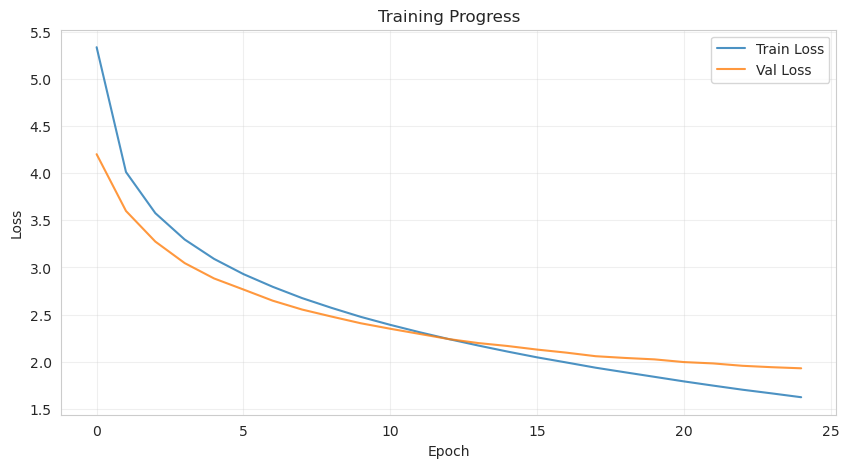

In [12]:
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transformer = transformer.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

# Initialize visualizer
class TrainingVisualizer:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def update(self, train_loss, val_loss=None):
        self.train_losses.append(train_loss)
        if val_loss:
            self.val_losses.append(val_loss)

    def plot(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Train Loss', alpha=0.8)
        if self.val_losses:
            plt.plot(self.val_losses, label='Val Loss', alpha=0.8)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.title('Training Progress')
        plt.show()

viz = TrainingVisualizer()
transformer.train()

for epoch in range(num_epochs):
    # Training
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for src_data, tgt_data in progress_bar:
        src_data = src_data.to(device)
        tgt_data = tgt_data.to(device)

        optimizer.zero_grad()
        output = transformer(src_data, tgt_data[:, :-1])
        loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    transformer.eval()
    val_loss = 0
    with torch.no_grad():
        for src_data, tgt_data in val_loader:
            src_data = src_data.to(device)
            tgt_data = tgt_data.to(device)
            output = transformer(src_data, tgt_data[:, :-1])
            loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    transformer.train()

    # Update visualizer
    viz.update(avg_train_loss, avg_val_loss)

    print(f"Epoch: {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Plot final training curves
viz.plot()

Mit Parametern

`d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048`

und dem Multi30k Datensatz (29 000 Sätze im Train split) beobachten wir starkes Overfitting nach ca. 10 Epochen.

![Overfitting](./Overfitting.png)

Deshalb wählen wir ein kleineres (halbes) Netz für zukünftige Trainings:

`d_model = 256
num_heads = 4
num_layers = 3
d_ff = 1024
dropout = 0.3`

Scheinbar ist der Dropout mit 0.3 zu hoch, es wird wenig gelernt:

![Dropout too high](./dropout0_3_TooMuch.png)

Mit einem Dropout von 0.1 kommen wir in 25 Epochen zu einem guten Ergebnis.

![Loss finales Training](./final_loss.png)


In [25]:
def translate(model, src_sentence, src_vocab, tgt_vocab, max_len=50, device='cuda', temperature=1.0):
    model.eval()

    # Reverse vocab for decoding
    idx_to_tgt = {idx: token for token, idx in tgt_vocab.items()}

    # Encode source sentence
    src_tokens = ["<sos>"] + src_sentence.split() + ["<eos>"]
    src_indices = [src_vocab.get(tok, src_vocab["<unk>"]) for tok in src_tokens]
    src_tensor = torch.tensor([src_indices]).to(device)

    # Start with <sos> token
    tgt_indices = [tgt_vocab["<sos>"]]

    with torch.no_grad():
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices]).to(device)

            output = model(src_tensor, tgt_tensor)

            # Get next token prediction
            next_token_logits = output[0, -1, :] / temperature

            # Prevent <pad>, <sos>, <unk> from being generated
            next_token_logits[tgt_vocab["<pad>"]] = -float('inf')
            next_token_logits[tgt_vocab["<sos>"]] = -float('inf')
            next_token_logits[tgt_vocab["<unk>"]] = -float('inf')

            next_token = next_token_logits.argmax().item()

            if next_token == tgt_vocab["<eos>"]:
                break

            tgt_indices.append(next_token)

    # Decode to text
    translated_tokens = [idx_to_tgt.get(idx, "<unk>") for idx in tgt_indices[1:]]  # Skip <sos>
    return " ".join(translated_tokens)

Original: Zwei Menschen sitzen vor einem Baum.
Translation: Two people are sitting in front of a tree.


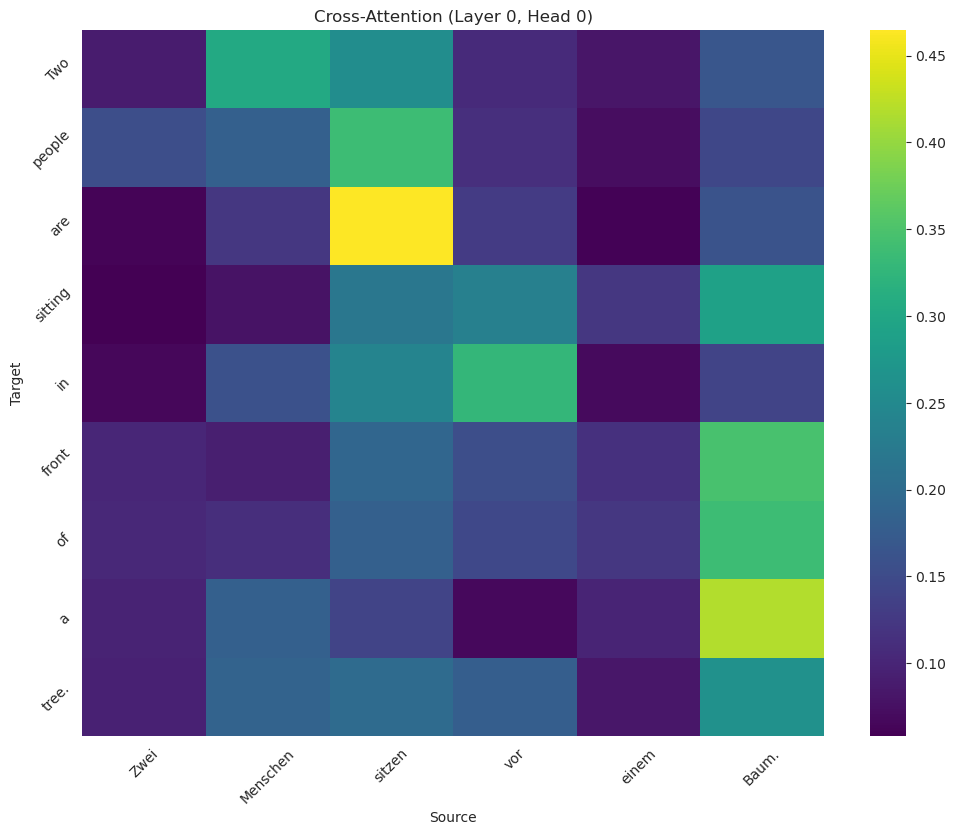

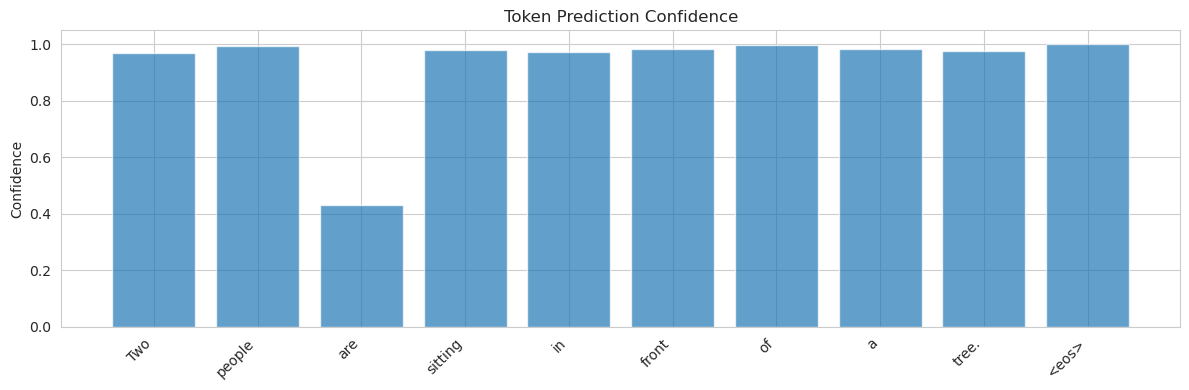

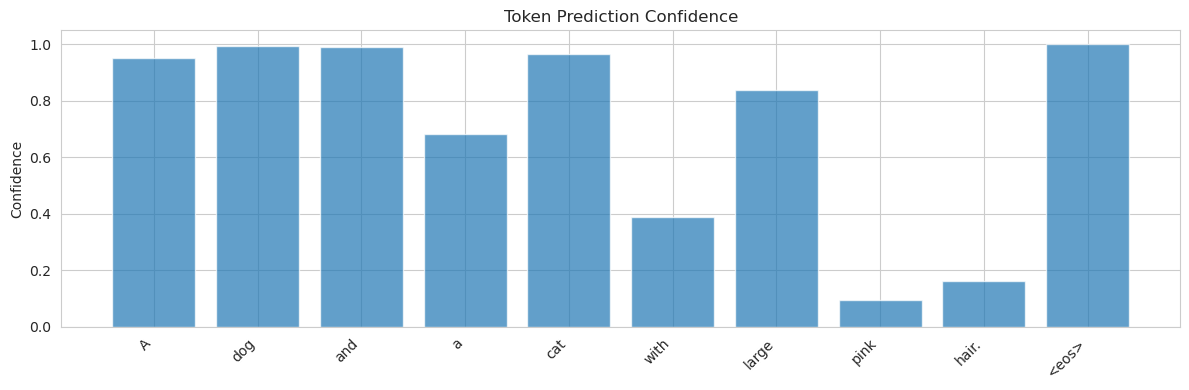

In [59]:
sentence = "Zwei Menschen sitzen vor einem Baum."
translation = translate(transformer, sentence, src_vocab, tgt_vocab)
print("Original:", sentence)
print("Translation:", translation)

visualize_attention(transformer, sentence, translation, src_vocab, tgt_vocab, device=device)

visualize_prediction_confidence(transformer, sentence, src_vocab, tgt_vocab, device=device)

visualize_prediction_confidence(transformer, "Ein Hund und eine Katze mit großen Augen.", src_vocab, tgt_vocab, device=device)

## Ergebnisse

Die Beziehung zwischen Tokens in Input und Output wird durch Cross Attention deutlich. In diesem Beispiel sehen wir unter Anderem, dass "are" in Verbindung mit "sitzen" steht. ("sitzen" -> "are sitting")

![Cross Attention](./Cross-Attention.png)

Bei Sätzen die nicht korrekt übersetzt werden, können wir durch geringe Confidence sehen, welche Tokens vermutlich nicht passen.

Aus "Ein Hund und eine Katze mit großen Augen." wird "A dog and a cat with large *pink hair*."

![Low Confidence](./low_confidence.png)

In [62]:
# Test sentences generated by chatGPT-5.2
german_sentences = [
    "Ein Mann in einer blauen Jacke fährt mit dem Fahrrad durch eine Stadtstraße.",
    "Zwei Kinder spielen mit einem roten Ball in einem Park mit Rasenflächen.",
    "Eine Frau sitzt an einem Cafetisch und trinkt Kaffee.",
    "Eine Gruppe von Menschen überquert eine belebte Kreuzung.",
    "Ein Hund rennt durch den Schnee, während sein Besitzer zusieht.",
    "Ein kleiner Junge hält an einem sonnigen Tag eine Eistüte in der Hand.",
    "Mehrere Menschen warten auf dem Bahnsteig auf einen Zug.",
    "Ein Mann kocht in einer kleinen Küche.",
    "Eine Frau sitzt auf einer Bank und liest ein Buch.",
    "Zwei Männer tragen eine große Kiste in ein Gebäude.",
    "Eine Familie macht ein Picknick in der Nähe eines Sees.",
    "Ein Kind fährt mit einem Roller auf dem Bürgersteig.",
    "Eine Frau kauft Gemüse auf einem Markt im Freien.",
    "Ein Mann steht auf einer Leiter und streicht eine Wand.",
    "Drei Menschen sitzen auf dem Rasen und unterhalten sich.",
    "Ein Mädchen bläst Seifenblasen in einem Hinterhof.",
    "Eine Gruppe Radfahrer fährt auf einer Landstraße.",
    "Ein Mann spielt an einer Straßenecke Gitarre.",
    "Eine Frau schiebt einen Kinderwagen durch einen Park.",  # notice the chatGPT bias
    "Ein Hund springt ins Wasser, um einen Stock zu holen.",
    "Zwei Kinder bauen eine Sandburg am Strand.",
    "Ein Mann tippt an einem Schreibtisch auf einem Laptop.",
    "Eine Frau fotografiert ein historisches Gebäude.",
    "Mehrere Menschen stehen an einem Imbissstand Schlange.",
    "Ein Kind füttert Enten in der Nähe eines Teiches"
]

In [63]:
for sentence in german_sentences:
    translation = translate(transformer, sentence, src_vocab, tgt_vocab)
    print("Original:", sentence)
    print("Translation:", translation)
    print()


Original: Ein Mann in einer blauen Jacke fährt mit dem Fahrrad durch eine Stadtstraße.
Translation: A man in a blue jacket riding a bicycle through a city street.

Original: Zwei Kinder spielen mit einem roten Ball in einem Park mit Rasenflächen.
Translation: Two children play with a red ball in a park with a red ball

Original: Eine Frau sitzt an einem Cafetisch und trinkt Kaffee.
Translation: A woman sitting at a table drinking coffee

Original: Eine Gruppe von Menschen überquert eine belebte Kreuzung.
Translation: A group of people crossing a crowded street.

Original: Ein Hund rennt durch den Schnee, während sein Besitzer zusieht.
Translation: A dog runs through the air while his dog watches.

Original: Ein kleiner Junge hält an einem sonnigen Tag eine Eistüte in der Hand.
Translation: A young boy holds a paper on a sunny day.

Original: Mehrere Menschen warten auf dem Bahnsteig auf einen Zug.
Translation: Several people wait for a train.

Original: Ein Mann kocht in einer kleinen 

In [64]:
%%script echo skipping

torch.save(transformer, "./transformer.pt")

## Reflexion

Die Visualisierung der Attention und Token Prediction Confidence helfen beim Verständnis von Attention Mechanismen.

Das vergleichsweise gute Ergebnis der Übersetzungen ist auf den begrenzten Datensatz zurückzuführen.